In [ ]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("vivmankar/asian-vs-african-elephant-image-classification")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 51.8M/51.8M [00:02<00:00, 19.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/vivmankar/asian-vs-african-elephant-image-classification/versions/1
Contents of base_path (/root/.cache/kagglehub/datasets/vivmankar/asian-vs-african-elephant-image-classification/versions):
['1']
Contents of path (/root/.cache/kagglehub/datasets/vivmankar/asian-vs-african-elephant-image-classification/versions/1):
['dataset']


In [ ]:
import os

# Update path to match the 'dataset' directory in the elephant dataset
data_path = os.path.join(path, 'dataset')

# List subdirectories (usually 'train' and 'test' classes)
if os.path.exists(data_path):
    print(f"Classes in dataset: {os.listdir(data_path)}")
else:
    print(f"Directory not found: {data_path}")

Classes in dataset: ['test', 'train']



--- Sample Images from Dataset (/root/.cache/kagglehub/datasets/vivmankar/asian-vs-african-elephant-image-classification/versions/1/dataset) ---
Found 1028 images. Displaying 6 sample images:


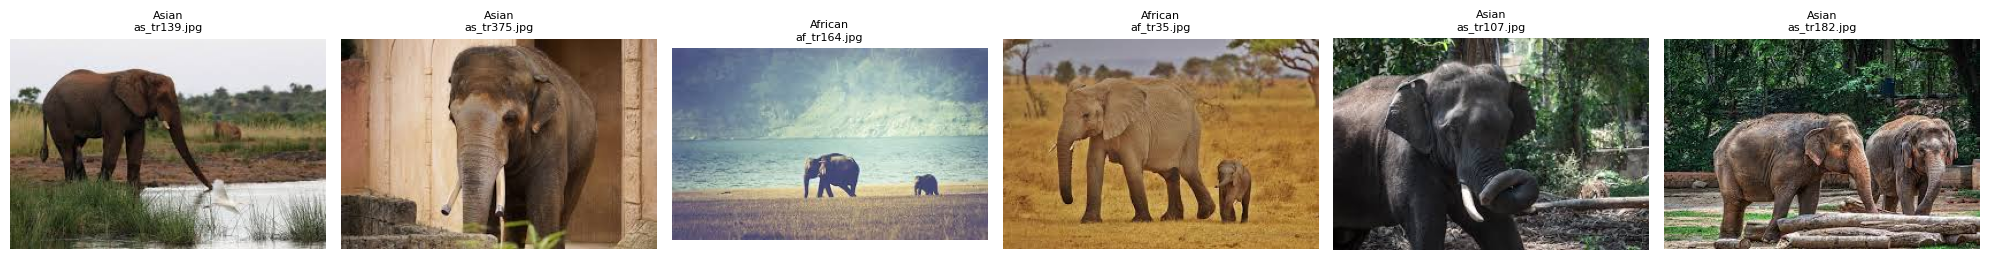

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images. Displaying {min(num_samples, len(all_image_paths))} sample images:")

    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            # Display class name (parent folder) and filename
            label = os.path.basename(os.path.dirname(img_path))
            axes[i].set_title(f"{label}\n{os.path.basename(img_path)}", fontsize=8)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Use the correct 'dataset' path
data_path = os.path.join(path, 'dataset')
print(f"\n--- Sample Images from Dataset ({data_path}) ---")
display_sample_images(data_path)

In [ ]:
import tensorflow as tf

# Check if GPU is available
gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print(f"GPU is available: {gpu_devices}")
    # Display GPU details
    !nvidia-smi
else:
    print("GPU is not available. Training will proceed on CPU.")

GPU is not available. Training will proceed on CPU.


In [ ]:
from tensorflow.keras.applications import MobileNet
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Configuration
img_height, img_width = 224, 224
batch_size = 32
data_dir = os.path.join(path, 'dataset')

# Data Preprocessing
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2 # Use 20% for validation
)

train_generator = train_datagen.flow_from_directory(
    os.path.join(data_dir, 'train'),
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    os.path.join(data_dir, 'train'),
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

# Build MobileNet Model
with tf.device('/GPU:0' if gpu_devices else '/CPU:0'):
    base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
    base_model.trainable = False # Freeze base layers

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(train_generator.num_classes, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Found 672 images belonging to 2 classes.
Found 168 images belonging to 2 classes.
17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.5952 - loss: 1.0330 - val_accuracy: 0.5714 - val_loss: 0.8033
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.6726 - loss: 0.6391 - val_accuracy: 0.6250 - val_loss: 0.6447
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.6994 - loss: 0.5757 - val_accuracy: 0.6429 - val_loss: 0.6228
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.7262 - loss: 0.5406 - val_accuracy: 0.6250 - val_loss: 0.6579
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.7039 - loss: 0.5633 - val_accuracy: 0.6726 - val_loss: 0.6143
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.7455 - loss: 0.5234 - val_accuracy: 0.6607 - val_loss: 0.6307
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.7485 - loss: 0.5100 - val_accuracy: 0.6667 - va

In [ ]:
# Summary of Training Results
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    os.path.join(data_dir, 'test'),
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical'
)

loss, accuracy = model.evaluate(test_generator)
print(f"\n--- Training Summary ---")
print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Found 188 images belonging to 2 classes.
6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.8670 - loss: 0.3055

--- Training Summary ---
Final Training Accuracy: 0.7902
Final Validation Accuracy: 0.6429
Test Accuracy: 0.8670


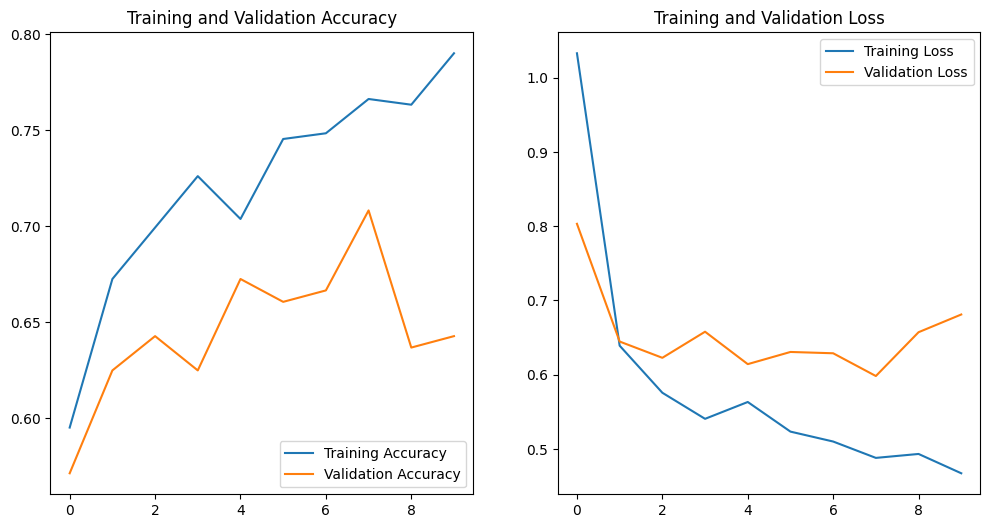

In [ ]:
# Visualization of Training Progress
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 6))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend(loc='lower right')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend(loc='upper right')

plt.show()